In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df2 = pd.read_csv("data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df3 = pd.read_csv("data/Friday-WorkingHours-Morning.pcap_ISCX.csv")
df4 = pd.read_csv("data/Monday-WorkingHours.pcap_ISCX.csv")
df5 = pd.read_csv("data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df6 = pd.read_csv("data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df7 = pd.read_csv("data/Tuesday-WorkingHours.pcap_ISCX.csv")
df8 = pd.read_csv("data/Wednesday-workingHours.pcap_ISCX.csv")

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df.shape


(225745, 79)

In [5]:
df2.shape

(286467, 79)

In [6]:
df3.shape

(191033, 79)

In [7]:
df4.shape

(529918, 79)

In [8]:
df4.shape

(529918, 79)

In [9]:
df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
105443,80,8154806,4,0,24,0,6,6,6.000000,0.000000,...,20,4.0,0.0,4,4,8154802.0,0.0,8154802,8154802,DDoS
115982,80,474411,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
148141,56412,2201094,1,6,6,36,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9635,80,119928428,112,116,97382,116926,2564,0,869.482143,1206.804663,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
72283,80,1869104,3,5,26,11601,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
127137,80,61731,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
48167,80,641975,3,6,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
12699,53,262,2,2,76,352,38,38,38.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
148616,80,9104735,4,0,24,0,6,6,6.000000,0.000000,...,20,1004.0,0.0,1004,1004,9103731.0,0.0,9103731,9103731,DDoS
30261,80,1274722,3,5,26,11601,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS


In [10]:
print(f"Total Potential Features: {df.shape[1]}")
print(f"Total sample data: {df.shape[0]}")

Total Potential Features: 79
Total sample data: 225745


In [11]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(2633)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-null  float64


In [14]:
print(type(df))
print(df.columns.tolist())
print(" Label" in df.columns)

<class 'pandas.DataFrame'>
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' A

<Axes: xlabel=' Label', ylabel='count'>

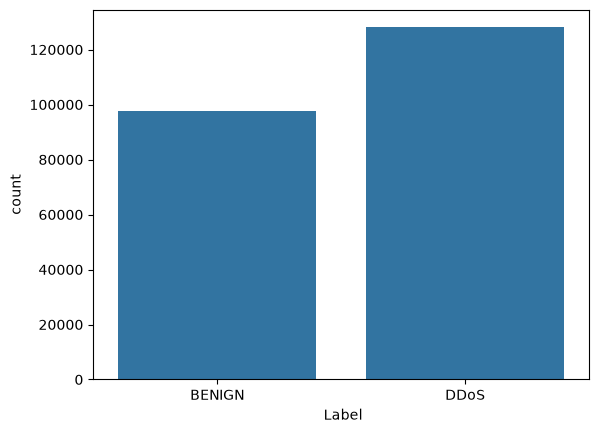

In [15]:
sns.countplot(data=df, x=df[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

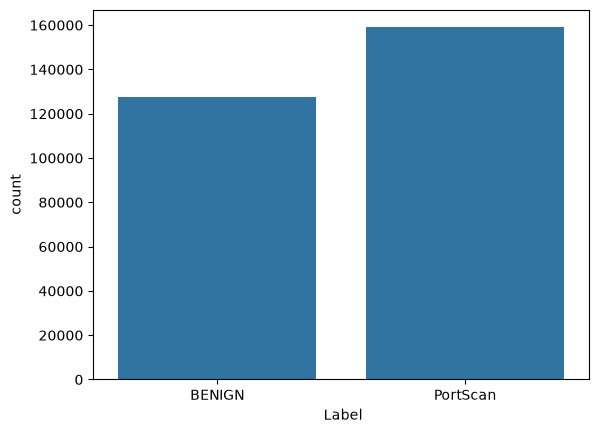

In [16]:
sns.countplot(data=df, x=df2[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

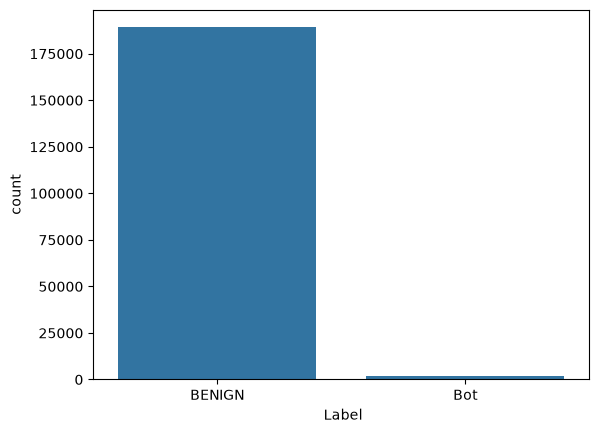

In [17]:
sns.countplot(data=df, x=df3[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

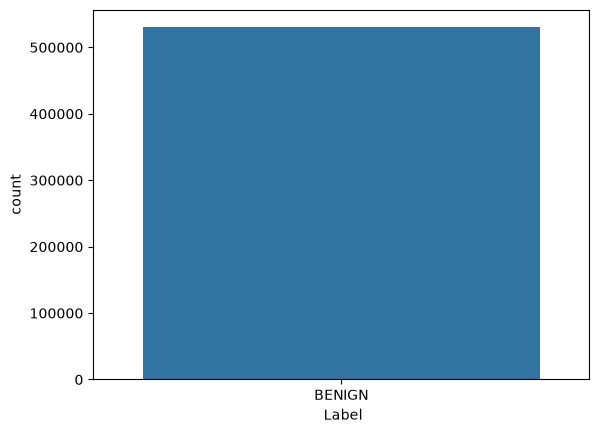

In [18]:
sns.countplot(data=df, x=df4[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

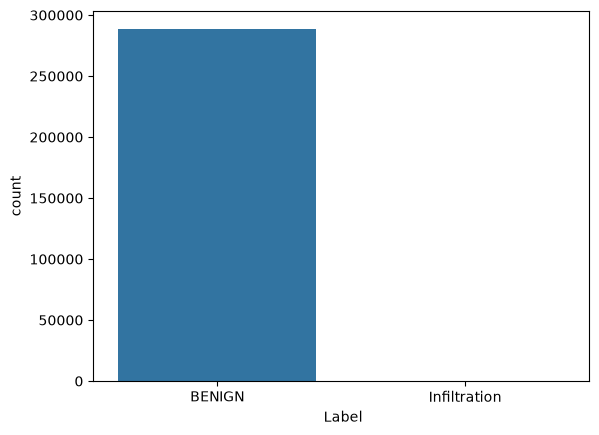

In [19]:
sns.countplot(data=df, x=df5[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

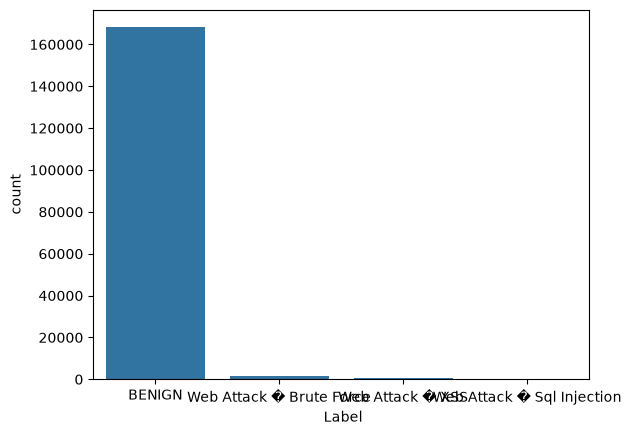

In [20]:
sns.countplot(data=df, x=df6[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

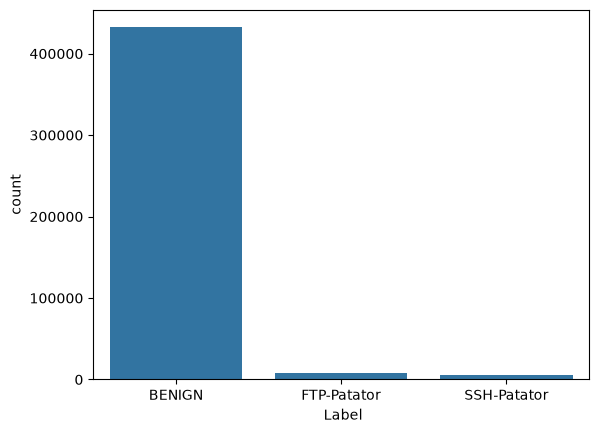

In [21]:
sns.countplot(data=df, x=df7[" Label"])

<Axes: xlabel=' Label', ylabel='count'>

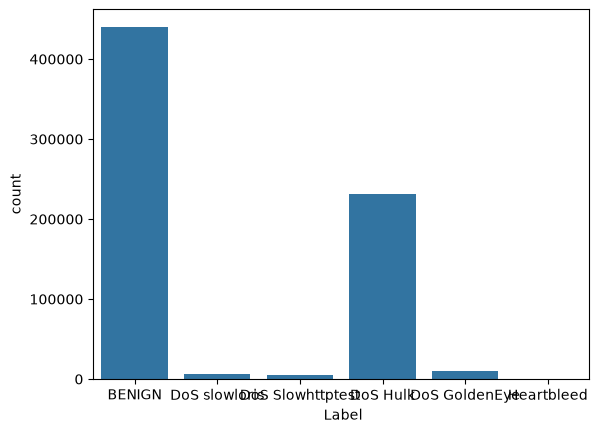

In [22]:
sns.countplot(data=df, x=df8[" Label"])

In [23]:
df_total = pd.concat([df, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)

In [24]:
df_total.shape

(2830743, 79)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-null  float64


In [26]:
df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
194789,49968,1039024,6,2,11601,26,4380,0,1933.500000,2189.772933,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
72693,80,6109578,4,0,24,0,6,6,6.000000,0.000000,...,20,706.0,0.0,706,706,6108872.0,0.0,6108872,6108872,DDoS
25173,80,413925,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
55149,80,527026,5,0,30,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
32809,51302,4611563,1,5,6,30,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
98055,80,80375139,8,4,56,11601,20,0,7.000000,5.656854,...,20,2214119.0,0.0,2214119,2214119,77700000.0,0.0,77700000,77700000,DDoS
181833,80,1590861,3,4,26,11601,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
53403,80,133173,4,0,24,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
223138,443,4365545,5,1,129,41,45,6,25.800000,18.780309,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
33712,80,8725775,4,0,24,0,6,6,6.000000,0.000000,...,20,1001.0,0.0,1001,1001,8724774.0,0.0,8724774,8724774,DDoS


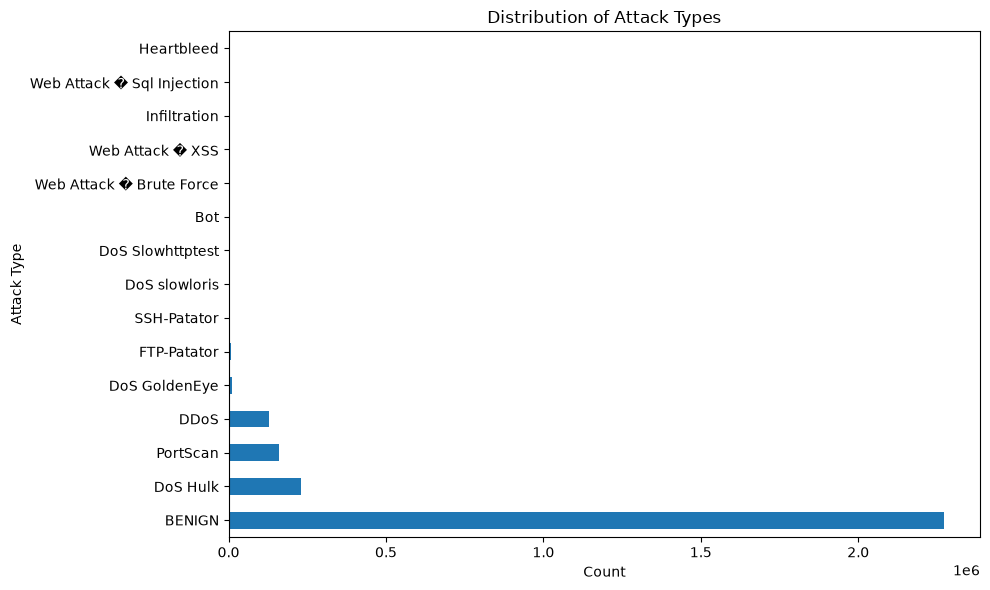

In [27]:
counts = df_total[" Label"].value_counts()

plt.figure(figsize=(10, 6))
counts.plot(kind="barh")

plt.title("Distribution of Attack Types")
plt.xlabel("Count")
plt.ylabel("Attack Type")

plt.tight_layout()
plt.show()

In [28]:
print(counts.index)

Index(['BENIGN', 'DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye',
       'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest',
       'Bot', 'Web Attack � Brute Force', 'Web Attack � XSS', 'Infiltration',
       'Web Attack � Sql Injection', 'Heartbleed'],
      dtype='str', name=' Label')


In [29]:
for col in df_total.columns:
    print(col)

 Destination Port
 Flow Duration
 Total Fwd Packets
 Total Backward Packets
Total Length of Fwd Packets
 Total Length of Bwd Packets
 Fwd Packet Length Max
 Fwd Packet Length Min
 Fwd Packet Length Mean
 Fwd Packet Length Std
Bwd Packet Length Max
 Bwd Packet Length Min
 Bwd Packet Length Mean
 Bwd Packet Length Std
Flow Bytes/s
 Flow Packets/s
 Flow IAT Mean
 Flow IAT Std
 Flow IAT Max
 Flow IAT Min
Fwd IAT Total
 Fwd IAT Mean
 Fwd IAT Std
 Fwd IAT Max
 Fwd IAT Min
Bwd IAT Total
 Bwd IAT Mean
 Bwd IAT Std
 Bwd IAT Max
 Bwd IAT Min
Fwd PSH Flags
 Bwd PSH Flags
 Fwd URG Flags
 Bwd URG Flags
 Fwd Header Length
 Bwd Header Length
Fwd Packets/s
 Bwd Packets/s
 Min Packet Length
 Max Packet Length
 Packet Length Mean
 Packet Length Std
 Packet Length Variance
FIN Flag Count
 SYN Flag Count
 RST Flag Count
 PSH Flag Count
 ACK Flag Count
 URG Flag Count
 CWE Flag Count
 ECE Flag Count
 Down/Up Ratio
 Average Packet Size
 Avg Fwd Segment Size
 Avg Bwd Segment Size
 Fwd Header Length.1
Fwd Avg